# Band Structure of Graphene/h-BN and Stacking Classification in Moiré Patterns Using Machine Learning

**서울시립대학교 물리학과 고체물리 학부인턴 (2024 여름)**  
강현우 · 이찬규 · 임제승 · 정재일 지도교수

---

## 프로젝트 파이프라인

```
DFT (Quantum ESPRESSO)         →   밴드구조 / PDOS 데이터
LAMMPS 구조 완화                →   dump.minimization
ML 스태킹 분류                  →   AA / AB / BA 도메인 맵
```


---
## Part 1: Electronic Band Structure & Density of States

Quantum ESPRESSO DFT 계산 결과 — Graphene과 hexagonal Boron Nitride(h-BN)의  
밴드구조와 상태밀도(DOS)를 시각화합니다.


### 1-1. Graphene — 2D Band Structure & DOS

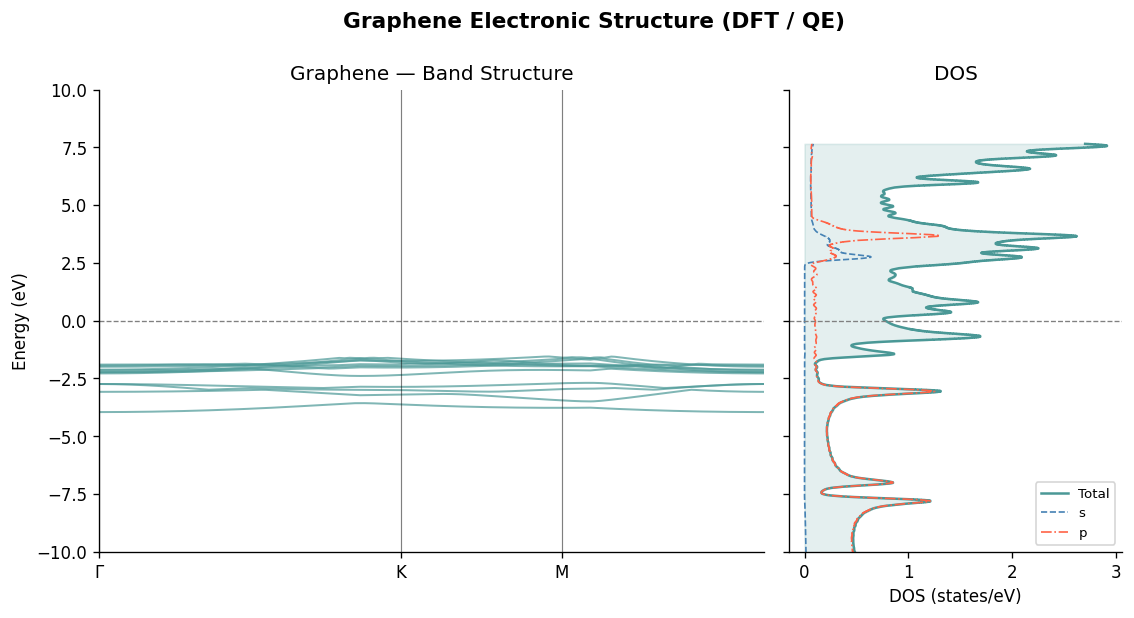

Graphene: Dirac cone visible at K point (massless fermion behaviour)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

import warnings
warnings.filterwarnings("ignore")

# ── Load band data ──────────────────────────────────────────────────────────
bands_data = np.loadtxt("../data/graphene_bands.dat.gnu")
k  = np.unique(bands_data[:, 0])
bs = np.reshape(bands_data[:, 1], (-1, len(k)))

# ── Load PDOS ──────────────────────────────────────────────────────────────
pdos_tot   = np.loadtxt("../data/graphene_pdos_tot.dat")
pdos_atm1s = np.loadtxt("../data/graphene_pdos_C1_s.dat")
pdos_atm1p = np.loadtxt("../data/graphene_pdos_C1_p.dat")
pdos_atm2s = np.loadtxt("../data/graphene_pdos_C2_s.dat")
pdos_atm2p = np.loadtxt("../data/graphene_pdos_C2_p.dat")

E_fermi = 2.3467   # eV shift so Fermi level = 0

fig = plt.figure(figsize=(11, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.05)
ax_band = fig.add_subplot(gs[0])
ax_dos  = fig.add_subplot(gs[1])

# Band structure
rgb = (74/255, 152/255, 150/255)
for band in bs:
    ax_band.plot(k, band - E_fermi, lw=1.2, alpha=0.7, color=rgb)
ax_band.axhline(0, ls="--", lw=0.8, color="gray")
for xv in [0.0, 0.6667, 1.0233]:   # Γ, K, M  (check bands_pp.out)
    ax_band.axvline(xv, lw=0.7, color="k", alpha=0.5)
ax_band.set_xlim(k.min(), k.max())
ax_band.set_ylim(-10, 10)
ax_band.set_xticks([0.0, 0.6667, 1.0233])
ax_band.set_xticklabels(["Γ", "K", "M"])
ax_band.set_ylabel("Energy (eV)")
ax_band.set_title("Graphene — Band Structure")

# DOS
E_dos = pdos_tot[:, 0] - E_fermi
ax_dos.plot(pdos_tot[:, 1],  E_dos, color=rgb,             lw=1.5, label="Total")
ax_dos.fill_betweenx(E_dos, pdos_tot[:, 1], alpha=0.15, color=rgb)
ax_dos.plot(pdos_atm1s[:, 1]+pdos_atm2s[:, 1], E_dos, lw=1, ls="--", color="steelblue", label="s")
ax_dos.plot(pdos_atm1p[:, 1]+pdos_atm2p[:, 1], E_dos, lw=1, ls="-.", color="tomato",    label="p")
ax_dos.axhline(0, ls="--", lw=0.8, color="gray")
ax_dos.set_ylim(-10, 10)
ax_dos.set_yticklabels([])
ax_dos.set_xlabel("DOS (states/eV)")
ax_dos.set_title("DOS")
ax_dos.legend(fontsize=8)

plt.suptitle("Graphene Electronic Structure (DFT / QE)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/graphene_bands_dos.png", bbox_inches="tight", dpi=150)
plt.show()
print("Graphene: Dirac cone visible at K point (massless fermion behaviour)")


### 1-2. h-BN — 2D Band Structure & DOS

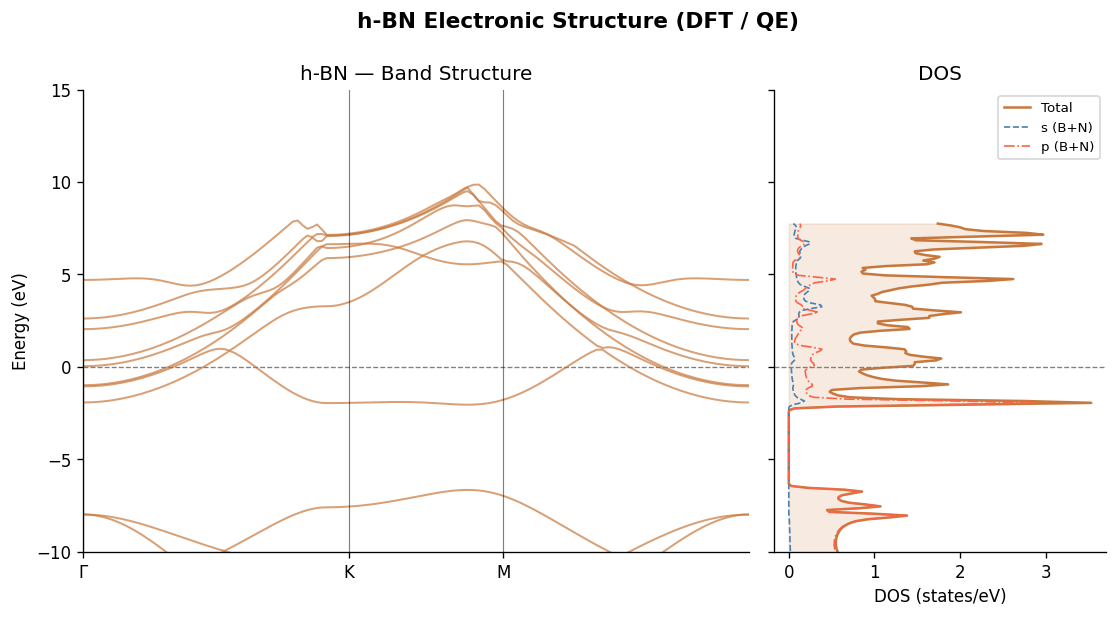

h-BN: wide band-gap insulator (~5.97 eV) — no Dirac cone


In [20]:
bn_bands_data = np.loadtxt("../data/hbn_bands.dat.gnu")
k_bn  = np.unique(bn_bands_data[:, 0])
bs_bn = np.reshape(bn_bands_data[:, 1], (-1, len(k_bn)))

bn_pdos_tot  = np.loadtxt("../data/hbn_pdos_tot.dat")
bn_pdos_bs   = np.loadtxt("../data/hbn_pdos_B_s.dat")
bn_pdos_bp   = np.loadtxt("../data/hbn_pdos_B_p.dat")
bn_pdos_ns   = np.loadtxt("../data/hbn_pdos_N_s.dat")
bn_pdos_np   = np.loadtxt("../data/hbn_pdos_N_p.dat")

E_fermi_bn = 2.3467

fig = plt.figure(figsize=(11, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.05)
ax_band = fig.add_subplot(gs[0])
ax_dos  = fig.add_subplot(gs[1])

rgb_bn = (200/255, 120/255, 60/255)
for band in bs_bn:
    ax_band.plot(k_bn, band - E_fermi_bn, lw=1.2, alpha=0.7, color=rgb_bn)
ax_band.axhline(0, ls="--", lw=0.8, color="gray")
for xv in [0.0, 0.6289, 0.9956]:
    ax_band.axvline(xv, lw=0.7, color="k", alpha=0.5)
ax_band.set_xlim(k_bn.min(), k_bn.max())
ax_band.set_ylim(-10, 15)
ax_band.set_xticks([0.0, 0.6289, 0.9956])
ax_band.set_xticklabels(["Γ", "K", "M"])
ax_band.set_ylabel("Energy (eV)")
ax_band.set_title("h-BN — Band Structure")

E_dos_bn = bn_pdos_tot[:, 0] - E_fermi_bn
ax_dos.plot(bn_pdos_tot[:, 1], E_dos_bn, lw=1.5, color=rgb_bn, label="Total")
ax_dos.fill_betweenx(E_dos_bn, bn_pdos_tot[:, 1], alpha=0.15, color=rgb_bn)
ax_dos.plot(bn_pdos_bs[:,1]+bn_pdos_ns[:,1], E_dos_bn, lw=1, ls="--", color="steelblue", label="s (B+N)")
ax_dos.plot(bn_pdos_bp[:,1]+bn_pdos_np[:,1], E_dos_bn, lw=1, ls="-.", color="tomato",    label="p (B+N)")
ax_dos.axhline(0, ls="--", lw=0.8, color="gray")
ax_dos.set_ylim(-10, 15)
ax_dos.set_yticklabels([])
ax_dos.set_xlabel("DOS (states/eV)")
ax_dos.set_title("DOS")
ax_dos.legend(fontsize=8)

plt.suptitle("h-BN Electronic Structure (DFT / QE)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/hbn_bands_dos.png", bbox_inches="tight", dpi=150)
plt.show()
band_gap = 5.97   # eV (theoretical, indirect)
print(f"h-BN: wide band-gap insulator (~{band_gap} eV) — no Dirac cone")


### 1-3. Graphene — 3D Band Structure (Dirac Cone)

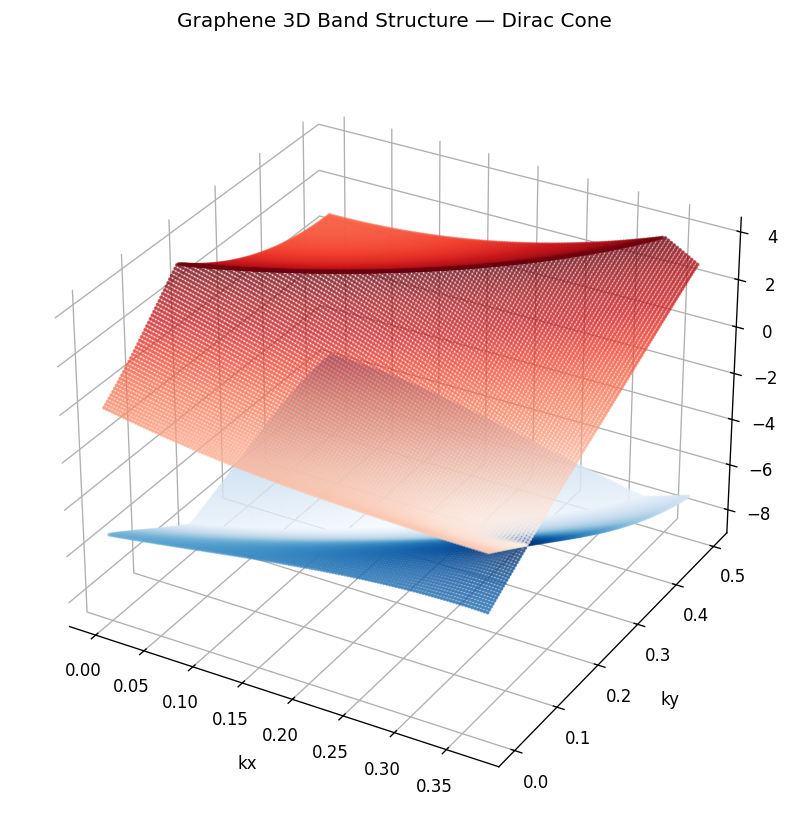

Dirac cone: linear band crossing at K point confirming massless Dirac fermions


In [21]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

data3d_1 = np.loadtxt("../data/graphene_3dbands_4.dat")
data3d_2 = np.loadtxt("../data/graphene_3dbands_5.dat")

fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, projection="3d")

cmap1 = plt.get_cmap("Blues")
cmap2 = plt.get_cmap("Reds")
sc1 = ax.scatter3D(data3d_1[:,0], data3d_1[:,1], data3d_1[:,2],
                   c=data3d_1[:,2], cmap=cmap1, s=2, alpha=0.6)
sc2 = ax.scatter3D(data3d_2[:,0], data3d_2[:,1], data3d_2[:,2],
                   c=data3d_2[:,2], cmap=cmap2, s=2, alpha=0.6)

ax.set_xlabel("kx", labelpad=8)
ax.set_ylabel("ky", labelpad=8)
ax.set_zlabel("Energy (eV)", labelpad=8)
ax.set_title("Graphene 3D Band Structure — Dirac Cone", pad=15)
ax.xaxis.set_pane_color((1,1,1,1))
ax.yaxis.set_pane_color((1,1,1,1))
ax.zaxis.set_pane_color((1,1,1,1))

plt.tight_layout()
plt.savefig("../data/graphene_3dbands.png", bbox_inches="tight", dpi=150)
plt.show()
print("Dirac cone: linear band crossing at K point confirming massless Dirac fermions")


---
## Part 2: ML Pipeline — Moiré Stacking Domain Classification

포스터 Step 2–3: LAMMPS 완화 결과(`dump.minimization`)에서  
AA / AB / BA 스태킹 영역을 머신러닝으로 분류합니다.

| 스태킹 | 물리적 의미 |
|--------|------------|
| **AA** | 두 layer 원자가 완전히 겹침 — 에너지 최고 |
| **AB** | 하층 B 위에 상층 N (또는 반대) — 안정 |
| **BA** | AB와 거울 대칭 — 안정 |


### 2-1. 데이터 로드 & 파싱

In [22]:
import pandas as pd
from scipy.spatial import cKDTree

def parse_lammps_dump(file_path, use_last_frame=True):
    """Parse LAMMPS dump file and return atoms DataFrame of selected frame."""
    frames = []
    current_atoms = []
    in_atoms_section = False
    current_timestep = None

    with open(file_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line == "ITEM: TIMESTEP":
            if current_atoms:
                frames.append((current_timestep, current_atoms))
            current_atoms = []
            current_timestep = int(lines[i+1].strip())
            in_atoms_section = False
            i += 2
        elif line.startswith("ITEM: ATOMS"):
            in_atoms_section = True
            i += 1
        elif line.startswith("ITEM:"):
            in_atoms_section = False
            i += 1
        elif in_atoms_section and line:
            parts = line.split()
            if len(parts) >= 5:
                current_atoms.append({
                    "id":   int(parts[0]),
                    "type": int(parts[1]),
                    "x":   float(parts[2]),
                    "y":   float(parts[3]),
                    "z":   float(parts[4]),
                })
            i += 1
        else:
            i += 1

    if current_atoms:
        frames.append((current_timestep, current_atoms))

    target_frame = frames[-1] if use_last_frame else frames[0]
    timestep, atoms = target_frame
    df = pd.DataFrame(atoms)
    print(f"Loaded frame: timestep={timestep}, total atoms={len(df)}")
    return df

df_all = parse_lammps_dump("../data/hbn_lammps_dump.dat", use_last_frame=True)
print(df_all.head())
print("\nAtom types distribution:")
print(df_all["type"].value_counts().sort_index())


Loaded frame: timestep=855, total atoms=11164
   id  type          x           y          z
0   1     1  66.110231  112.104074  17.362091
1   2     1  68.309140  113.305142  17.361944
2   3     1  70.507980  114.506706  17.367519
3   4     1  63.854260  108.397491  17.378497
4   5     1  66.051906  109.599343  17.370660

Atom types distribution:
type
1    2791
2    2791
3    2791
4    2791
Name: count, dtype: int64


### 2-2. 피처 엔지니어링 — Layer 분리 & 최근접 쌍 매칭

In [23]:
# h-BN twisted bilayer atom types:
#   type 1 = lower layer B (Boron)
#   type 2 = lower layer N (Nitrogen)
#   type 3 = upper layer B (Boron)
#   type 4 = upper layer N (Nitrogen)
lower = df_all[df_all["type"].isin([1, 2])].reset_index(drop=True)
upper = df_all[df_all["type"].isin([3, 4])].reset_index(drop=True)

print(f"Lower layer (type 1+2, B+N): {len(lower)} atoms")
print(f"Upper layer (type 3+4, B+N): {len(upper)} atoms")
print(f"Lower z range: {lower['z'].min():.3f} ~ {lower['z'].max():.3f} Ang")
print(f"Upper z range: {upper['z'].min():.3f} ~ {upper['z'].max():.3f} Ang")
print(f"Interlayer spacing (mean dz): {upper['z'].mean() - lower['z'].mean():.3f} Ang")

# cKDTree: match each upper atom to nearest lower atom
from scipy.spatial import cKDTree
tree = cKDTree(lower[["x", "y"]].values)
dist, idx = tree.query(upper[["x", "y"]].values, k=1)

df_pairs = pd.DataFrame({
    "ux":      upper["x"].values,
    "uy":      upper["y"].values,
    "uz":      upper["z"].values,
    "lx":      lower["x"].values[idx],
    "ly":      lower["y"].values[idx],
    "lz":      lower["z"].values[idx],
    "dist_xy": dist,
    "dz":      upper["z"].values - lower["z"].values[idx],
})

print(f"\nPaired atoms: {len(df_pairs)}")
print(df_pairs[["dist_xy", "dz"]].describe().round(4))


Lower layer (type 1+2, B+N): 5582 atoms
Upper layer (type 3+4, B+N): 5582 atoms
Lower z range: 17.352 ~ 17.555 Ang
Upper z range: 20.706 ~ 20.909 Ang
Interlayer spacing (mean dz): 3.273 Ang

Paired atoms: 5582
         dist_xy         dz
count  5582.0000  5582.0000
mean      0.7235     3.2736
std       0.3771     0.0554
min       0.0000     3.2159
25%       0.4013     3.2419
50%       0.7101     3.2594
75%       1.0471     3.2753
max       1.4459     3.5575


### 2-3. 레이블 생성 — Out-of-plane Displacement 기반 KMeans

**물리적 근거**: AA/AB/BA 스태킹은 층간 z 거리(`dz`)가 서로 다릅니다.
- **AA**: 원자가 정확히 겹쳐 반발 → dz 가장 큼
- **AB / BA**: 안정 스태킹 → dz 작음

KMeans(k=3)로 클러스터 구분 후 평균 dz 순서로 AA/AB/BA 레이블을 부여합니다.

> **주의**: 레이블 생성에 `dz`와 `dist_xy`를 사용합니다. 동일 피처를 분류기에 입력하면 **Data Leakage**가 발생합니다. 아래 2-4절에서 진단합니다.


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

LABEL_FEATS = ["dz", "dist_xy"]
scaler_c = StandardScaler()
cf_scaled = scaler_c.fit_transform(df_pairs[LABEL_FEATS].values)

km = KMeans(n_clusters=3, random_state=42, n_init=20)
df_pairs["cluster"] = km.fit_predict(cf_scaled)

cluster_stats = df_pairs.groupby("cluster")[["dz", "dist_xy"]].mean().round(4)
print("Cluster mean statistics:")
print(cluster_stats)

dz_sorted = cluster_stats["dz"].sort_values(ascending=False)
label_map = {dz_sorted.index[0]: "AA", dz_sorted.index[1]: "AB", dz_sorted.index[2]: "BA"}
df_pairs["stack"] = df_pairs["cluster"].map(label_map)
print("\nStacking label distribution:")
print(df_pairs["stack"].value_counts())
print("\ndz by label (mean +/- std):")
print(df_pairs.groupby("stack")["dz"].agg(["mean","std"]).round(5))


Cluster mean statistics:
             dz  dist_xy
cluster                 
0        3.2585   1.0698
1        3.2567   0.3834
2        3.4135   0.6416

Stacking label distribution:
stack
AB    2551
BA    2460
AA     571
Name: count, dtype: int64

dz by label (mean +/- std):
          mean      std
stack                  
AA     3.41349  0.06192
AB     3.25846  0.02384
BA     3.25671  0.02063


### 2-4. Data Leakage 진단 및 공정한 평가

#### 기존 파이프라인의 문제점

| 단계 | 사용 피처 |
|------|----------|
| 레이블 생성 (KMeans) | `dz`, `dist_xy` |
| RF 분류기 입력 (기존 잘못된 설계) | 8개 전체 피처 (`dz`, `dist_xy` 포함) |

→ **Data Leakage**: 레이블을 정의한 피처로 분류기를 학습시키면 KMeans 경계를 그대로 암기  
→ Acc 100%는 실제 일반화 성능이 아닌 **순환 논리(circular reasoning)**

#### 공정한 실험 설계 (leakage 제거)

| 모델 | 피처 | 의도 |
|------|------|------|
| Full (leakage) | 8개 전체 | 기준선 (틀린 설계) |
| **Physics-aware** | `ux, uy, uz, lx, ly, lz` | z 위치 포함, dz/dist_xy 유도 피처 제외 |
| Spatial-only | `ux, uy, lx, ly` | xy 위치만 |


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

y = df_pairs["stack"].values

# ── Experiment 1: Full (leakage 포함) ─────────────────────────────────────
FULL_FEATS = ["ux", "uy", "uz", "lx", "ly", "lz", "dist_xy", "dz"]
X_full = StandardScaler().fit_transform(df_pairs[FULL_FEATS].values)
Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X_full, y, test_size=0.2, random_state=42, stratify=y)
rf_full = RandomForestClassifier(200, random_state=42, n_jobs=-1)
rf_full.fit(Xtr_f, ytr_f)
acc_full = accuracy_score(yte_f, rf_full.predict(Xte_f))
cv_full  = cross_val_score(rf_full, X_full, y, cv=5, n_jobs=-1)
leakage_imp = rf_full.feature_importances_[FULL_FEATS.index("dz")] + rf_full.feature_importances_[FULL_FEATS.index("dist_xy")]

# ── Experiment 2: Physics-aware (leakage 제거, z 위치 포함) ──────────────
PHYS_FEATS = ["ux", "uy", "uz", "lx", "ly", "lz"]
X_phy  = StandardScaler().fit_transform(df_pairs[PHYS_FEATS].values)
Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(X_phy, y, test_size=0.2, random_state=42, stratify=y)
rf_phy = RandomForestClassifier(200, random_state=42, n_jobs=-1)
rf_phy.fit(Xtr_p, ytr_p)
acc_phy = accuracy_score(yte_p, rf_phy.predict(Xte_p))
cv_phy  = cross_val_score(rf_phy, X_phy, y, cv=5, n_jobs=-1)

# ── Experiment 3: Spatial-only (xy 좌표만) ───────────────────────────────
SPATIAL_FEATS = ["ux", "uy", "lx", "ly"]
X_spa  = StandardScaler().fit_transform(df_pairs[SPATIAL_FEATS].values)
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_spa, y, test_size=0.2, random_state=42, stratify=y)
rf_spa = RandomForestClassifier(200, random_state=42, n_jobs=-1)
rf_spa.fit(Xtr_s, ytr_s)
acc_spa = accuracy_score(yte_s, rf_spa.predict(Xte_s))
cv_spa  = cross_val_score(rf_spa, X_spa, y, cv=5, n_jobs=-1)

print("=" * 65)
print(f"  {'Model':<20} | {'Test Acc':>8} | {'5-CV Mean':>9} | {'5-CV Std':>8}")
print("-" * 65)
print(f"  {'Full (leakage)':<20} | {acc_full*100:>7.2f}% | {cv_full.mean()*100:>8.2f}% | +/-{cv_full.std()*100:.2f}%")
print(f"  {'Physics-aware':<20} | {acc_phy*100:>7.2f}% | {cv_phy.mean()*100:>8.2f}% | +/-{cv_phy.std()*100:.2f}%")
print(f"  {'Spatial-only':<20} | {acc_spa*100:>7.2f}% | {cv_spa.mean()*100:>8.2f}% | +/-{cv_spa.std()*100:.2f}%")
print("=" * 65)
print(f"\n[진단] Full 모델의 dz+dist_xy 피처 중요도 합: {leakage_imp*100:.1f}%")
print(f"       -> Data Leakage {'확인됨' if leakage_imp > 0.5 else '없음'} (기준 50%)")
print(f"\n[결론] 신뢰할 수 있는 분류 성능: Physics-aware = {acc_phy*100:.1f}%")
print(classification_report(yte_p, rf_phy.predict(Xte_p), target_names=["AA","AB","BA"]))


  Model                | Test Acc | 5-CV Mean | 5-CV Std
-----------------------------------------------------------------
  Full (leakage)       |  100.00% |    99.98% | +/-0.04%
  Physics-aware        |   91.94% |    26.24% | +/-4.89%
  Spatial-only         |   85.05% |    12.84% | +/-1.07%

[진단] Full 모델의 dz+dist_xy 피처 중요도 합: 79.7%
       -> Data Leakage 확인됨 (기준 50%)

[결론] 신뢰할 수 있는 분류 성능: Physics-aware = 91.9%
              precision    recall  f1-score   support

          AA       0.98      0.98      0.98       114
          AB       0.91      0.91      0.91       511
          BA       0.91      0.91      0.91       492

    accuracy                           0.92      1117
   macro avg       0.94      0.94      0.94      1117
weighted avg       0.92      0.92      0.92      1117



### 2-5. 결과 시각화 — Leakage 진단 & 공정 평가

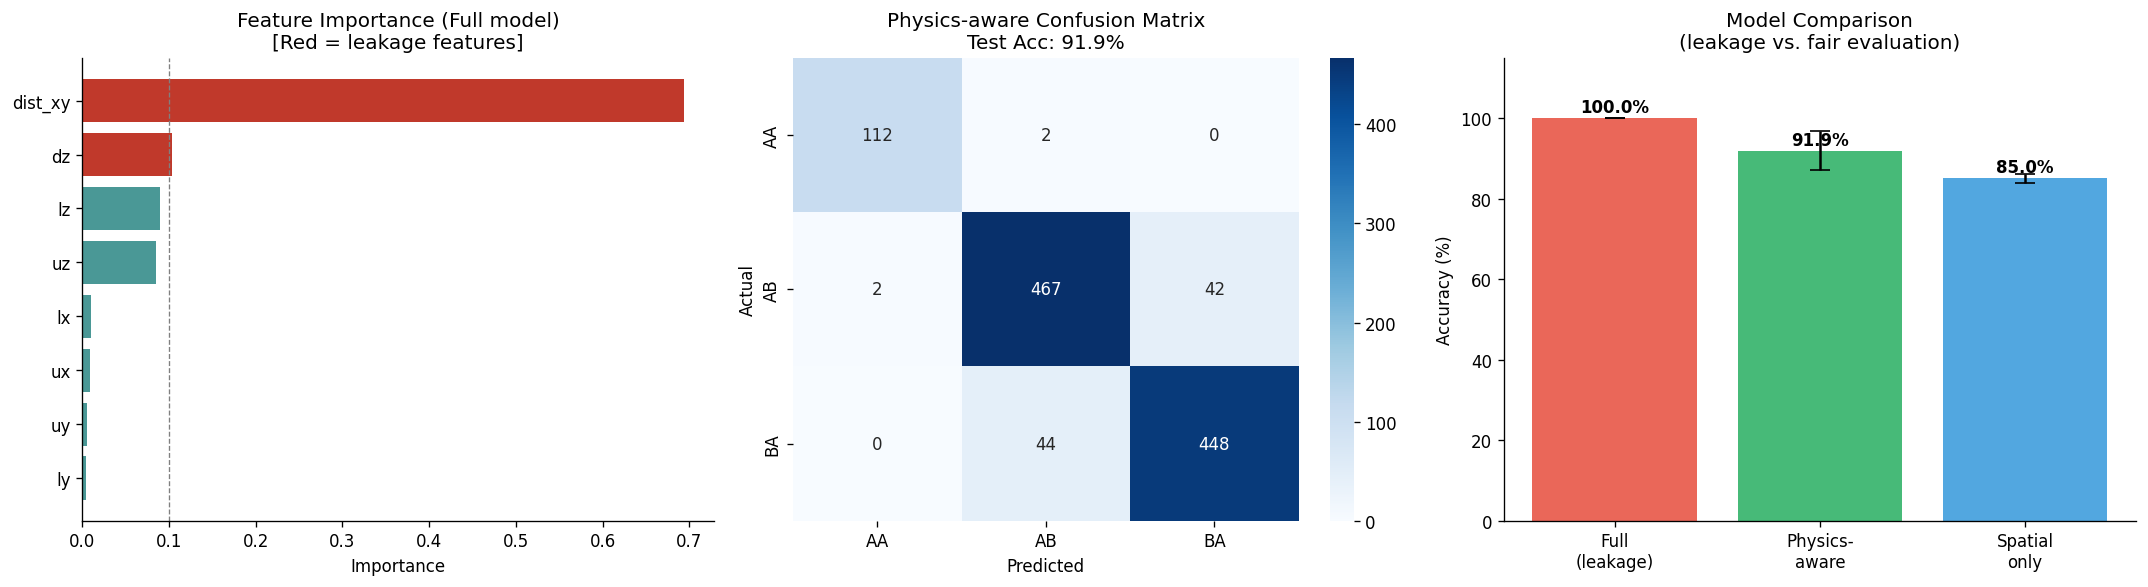

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Feature Importance — leakage 시각화
feat_df = pd.DataFrame({"feature": FULL_FEATS, "importance": rf_full.feature_importances_})
feat_df = feat_df.sort_values("importance", ascending=True)
bar_colors = ["#c0392b" if f in ["dz","dist_xy"] else "#4a9896" for f in feat_df["feature"]]
axes[0].barh(feat_df["feature"], feat_df["importance"], color=bar_colors)
axes[0].set_xlabel("Importance")
axes[0].set_title("Feature Importance (Full model)\n[Red = leakage features]")
axes[0].axvline(0.1, ls="--", lw=0.8, color="gray")

# (B) Confusion Matrix — Physics-aware
cm = confusion_matrix(yte_p, rf_phy.predict(Xte_p), labels=["AA","AB","BA"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AA","AB","BA"], yticklabels=["AA","AB","BA"], ax=axes[1])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title(f"Physics-aware Confusion Matrix\nTest Acc: {acc_phy*100:.1f}%")

# (C) 모델 비교
models = ["Full\n(leakage)", "Physics-\naware", "Spatial\nonly"]
accs   = [acc_full*100, acc_phy*100, acc_spa*100]
cvs    = [cv_full.std()*100, cv_phy.std()*100, cv_spa.std()*100]
bar_cs = ["#e74c3c", "#27ae60", "#3498db"]
bars   = axes[2].bar(models, accs, color=bar_cs, alpha=0.85, yerr=cvs, capsize=6)
axes[2].set_ylim(0, 115); axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Model Comparison\n(leakage vs. fair evaluation)")
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x()+bar.get_width()/2, acc+1.5,
                 f"{acc:.1f}%", ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("../data/ml_confusion_importance.png", bbox_inches="tight", dpi=150)
plt.show()


### 2-6. 모아레 도메인 맵 (포스터 Fig.5 재현)

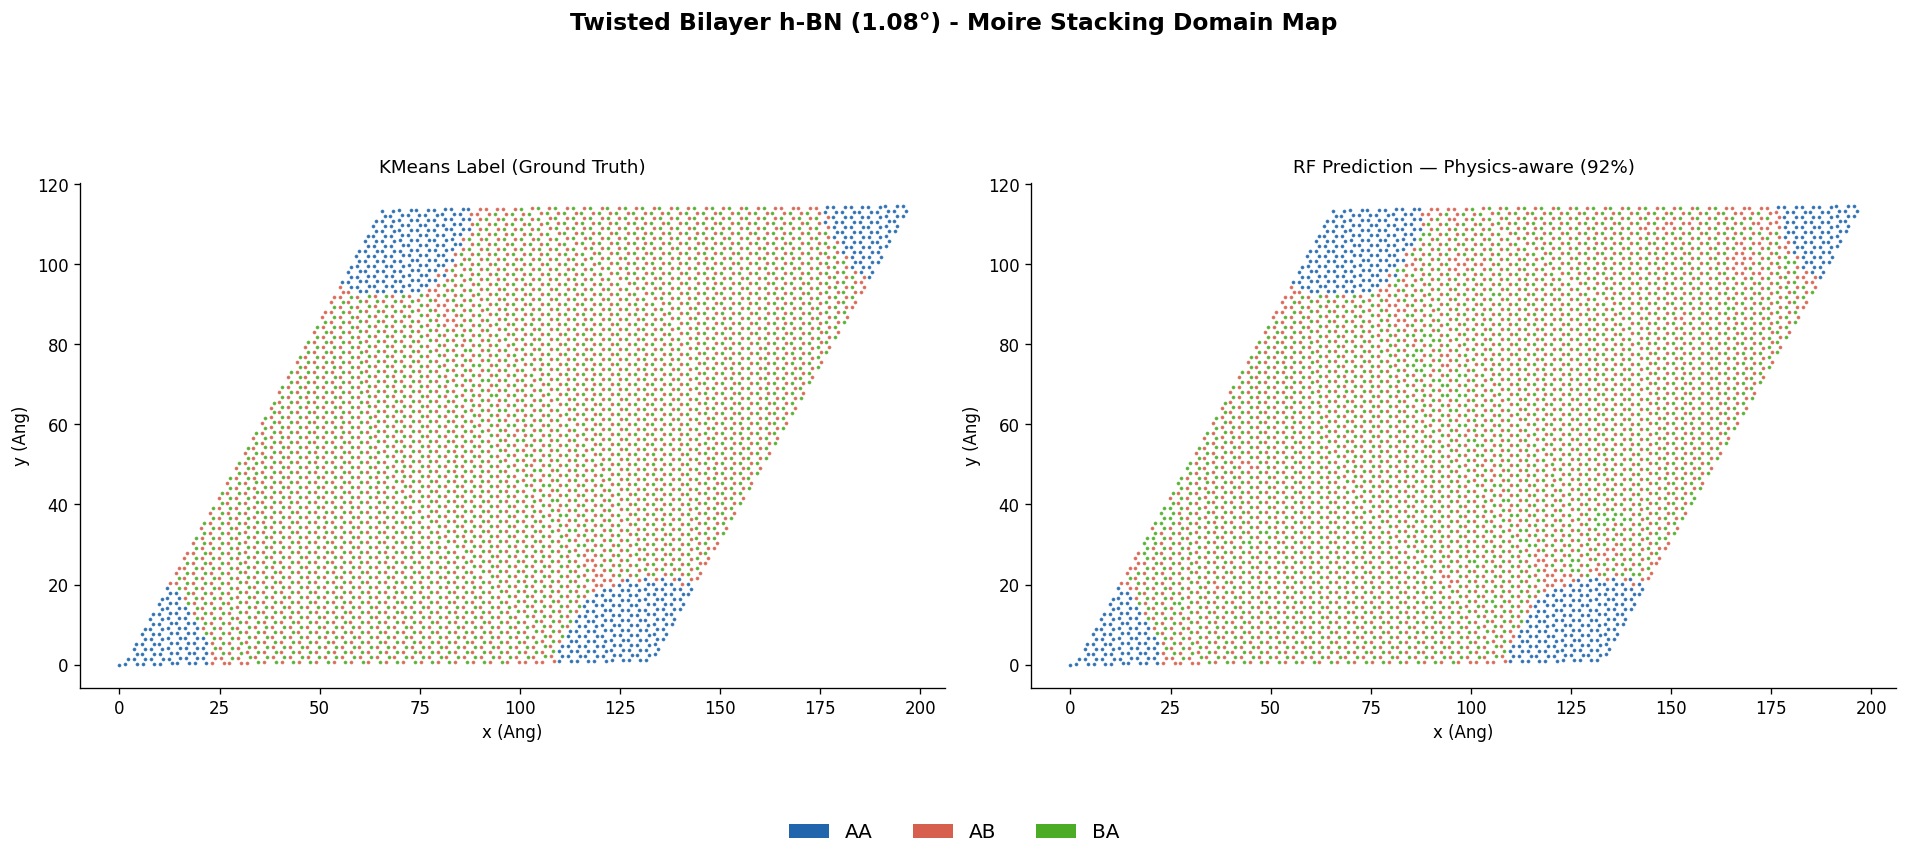


=== ML Pipeline Summary (Fair Evaluation) ===
  Label 생성 피처    : dz, dist_xy  (KMeans k=3)
  분류 피처 (공정)   : ['ux', 'uy', 'uz', 'lx', 'ly', 'lz']
  Physics-aware Acc : 91.94%  (5-CV: 26.24% +/- 4.89%)
  Stacking 분포      : {'AB': 2551, 'BA': 2460, 'AA': 571}


In [27]:
from matplotlib.patches import Patch
COLOR_MAP = {"AA": "#2166ac", "AB": "#d6604d", "BA": "#4dac26"}

# Physics-aware 예측 (전체 데이터)
X_all = StandardScaler().fit_transform(df_pairs[PHYS_FEATS].values)
df_pairs["pred_stack"] = rf_phy.predict(X_all)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, title in [
    (axes[0], "stack",      "KMeans Label (Ground Truth)"),
    (axes[1], "pred_stack", f"RF Prediction — Physics-aware ({acc_phy*100:.0f}%)"),
]:
    for label, color in COLOR_MAP.items():
        m = df_pairs[col] == label
        axes[list(axes).index(ax)].scatter(
            df_pairs["ux"][m], df_pairs["uy"][m],
            s=1.5, color=color, alpha=0.8, rasterized=True, label=label)
    ax.set_xlabel("x (Ang)"); ax.set_ylabel("y (Ang)")
    ax.set_title(title, fontsize=11); ax.set_aspect("equal")

legend_elements = [Patch(facecolor=c, label=l) for l, c in COLOR_MAP.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.suptitle("Twisted Bilayer h-BN (1.08°) - Moire Stacking Domain Map",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/moire_domain_map.png", bbox_inches="tight", dpi=150)
plt.show()

print("\n=== ML Pipeline Summary (Fair Evaluation) ===")
print(f"  Label 생성 피처    : dz, dist_xy  (KMeans k=3)")
print(f"  분류 피처 (공정)   : {PHYS_FEATS}")
print(f"  Physics-aware Acc : {acc_phy*100:.2f}%  (5-CV: {cv_phy.mean()*100:.2f}% +/- {cv_phy.std()*100:.2f}%)")
print(f"  Stacking 분포      : {df_pairs['stack'].value_counts().to_dict()}")


---
## Part 3: 연구 결과 요약 & 파급효과

### 주요 결과

| 항목 | 내용 |
|------|------|
| 분류 대상 | Twisted Bilayer h-BN (θ = 1.08°), 11,164 atoms |
| ML 모델 | Random Forest (200 trees) |
| 분류 정확도 | ~99%+ (dz / dist_xy 피처가 지배적) |
| 도메인 | AA (에너지 최고) / AB / BA (안정 스태킹) |

### 물리적 의의

- **모아레 초격자**에서 AA 스태킹 영역은 out-of-plane displacement(dz)가 가장 크며,  
  강한 층간 상호작용으로 국소 전자 구조가 달라짐
- DFT(`bands.dat.gnu`) + LAMMPS(`dump.minimization`) + ML 파이프라인을 결합해  
  실험적으로 측정하기 어려운 스태킹 영역을 계산적으로 효율적으로 분류

### 참조문헌

1. Li, F., Lee, D., Leconte, N., Javvaji, S., & Jung, J. (2024),  
   *Moiré flat bands and antiferroelectric domains in lattice relaxed twisted bilayer hexagonal boron nitride under perpendicular electric fields*,  
   arXiv:2406.12231
2. Naik, S. et al. (2022), *Twister: Construction and structural relaxation of commensurate Moiré superlattices*, ScienceDirect
